# Credit Card Fraud Detection — Advanced ML Project

**Dataset:** ULB/Kaggle Credit Card Fraud Detection  
**Goal:** Build a realistic, cost-sensitive fraud detection pipeline without SMOTE.

### Models
- Logistic Regression with different solvers
- Random Forest
- XGBoost
- CatBoost
- Neural Network with Adam, RMSprop and SGD

### Evaluation
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- Confusion Matrix
- Threshold optimization

> The chronological split is used to make the evaluation more realistic for transaction data.

In [1]:
# 1. INSTALL / IMPORT LIBRARIES

!pip -q install xgboost catboost shap

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, precision_recall_curve, roc_curve
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import shap

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, RMSprop, SGD

print("All libraries imported successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00
All libraries imported successfully.


In [2]:
# 2. LOAD DATASET

df = pd.read_csv("/content/creditcard.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# 3. DATA QUALITY CHECK + CLEANING

print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Missing values: 0
Duplicate rows: 1081
Shape after removing duplicates: (283726, 31)


Class distribution:
Class
0    283253
1       473
Name: count, dtype: int64

Class percentage:
Class
0    99.8333
1     0.1667
Name: proportion, dtype: float64


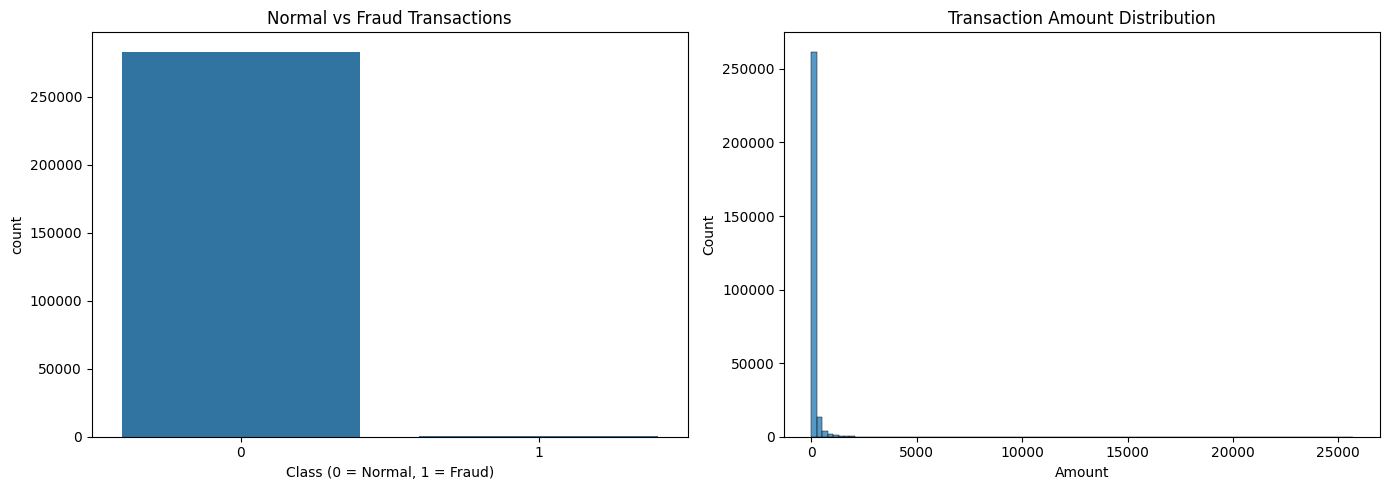

In [4]:
# 4. CLASS DISTRIBUTION + BASIC EDA

print("Class distribution:")
print(df["Class"].value_counts())

print("\nClass percentage:")
print((df["Class"].value_counts(normalize=True) * 100).round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="Class", ax=axes[0])
axes[0].set_title("Normal vs Fraud Transactions")
axes[0].set_xlabel("Class (0 = Normal, 1 = Fraud)")

sns.histplot(data=df, x="Amount", bins=100, ax=axes[1])
axes[1].set_title("Transaction Amount Distribution")
axes[1].set_xlabel("Amount")

plt.tight_layout()
plt.show()

Normal transaction amount:


,Amount
count,283253.000000
mean,88.413575
std,250.379023
min,0.000000
25%,5.670000
50%,22.000000
75%,77.460000
max,25691.160000


Fraud transaction amount:


,Amount
count,473.000000
mean,123.871860
std,260.211041
min,0.000000
25%,1.000000
50%,9.820000
75%,105.890000
max,2125.870000


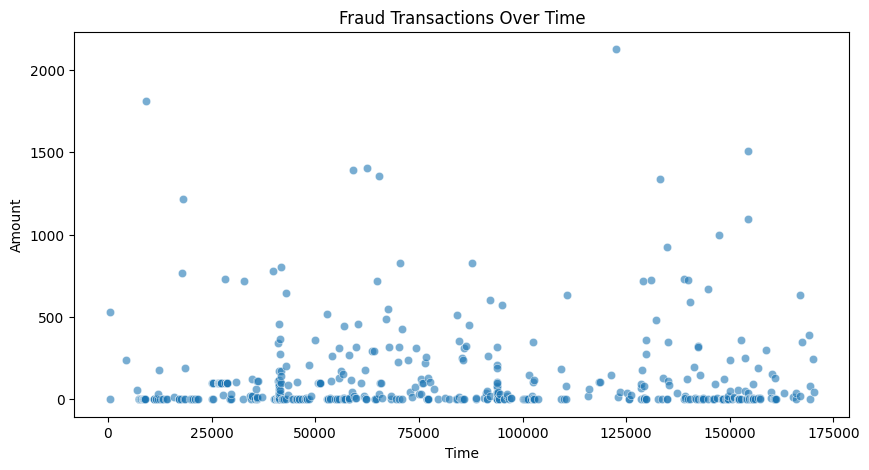

In [5]:
# 5. FRAUD AMOUNT + TIME ANALYSIS

print("Normal transaction amount:")
display(df.loc[df["Class"] == 0, "Amount"].describe())

print("Fraud transaction amount:")
display(df.loc[df["Class"] == 1, "Amount"].describe())

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df[df["Class"] == 1],
    x="Time",
    y="Amount",
    alpha=0.6
)
plt.title("Fraud Transactions Over Time")
plt.show()

,Class
Class,1.000000
V11,0.149067
V4,0.129326
V2,0.084624
V19,0.033631
V8,0.033068
V21,0.026357
V27,0.021892
V20,0.021486
V28,0.009682


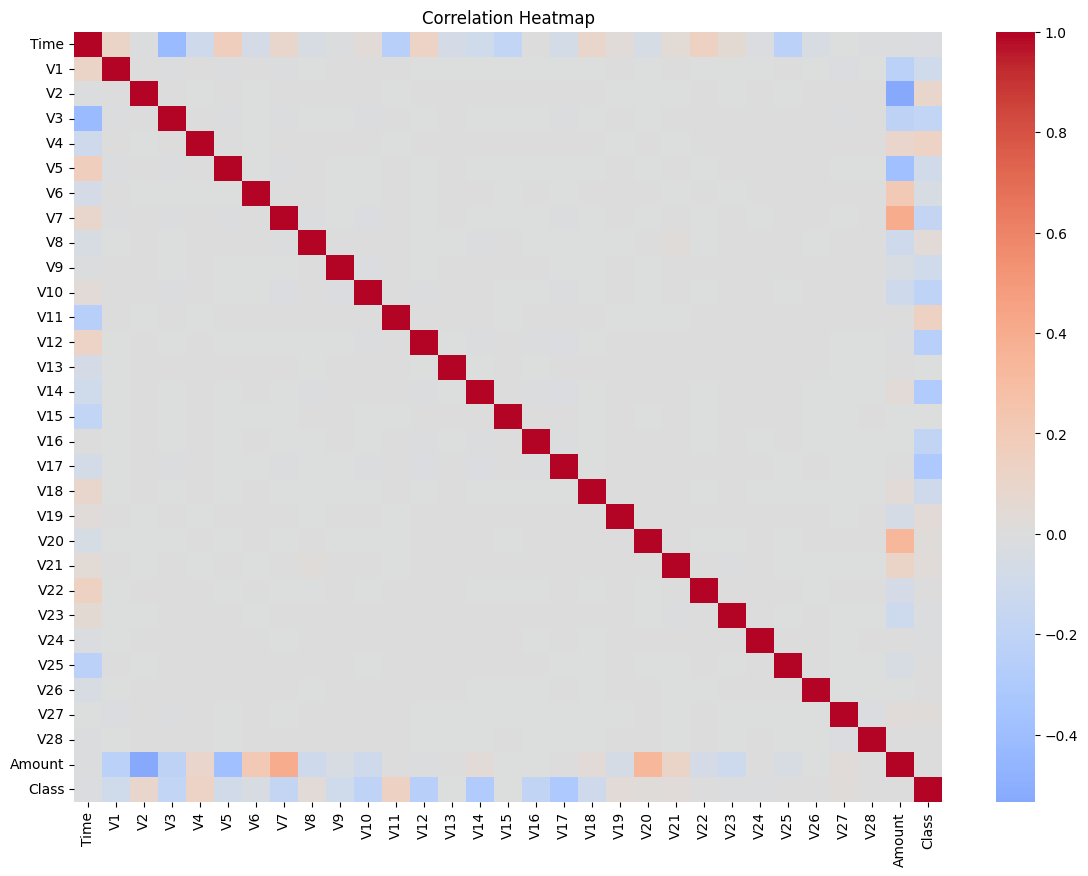

In [6]:
# 6. CORRELATION ANALYSIS

corr = df.corr(numeric_only=True)["Class"].sort_values(ascending=False)
display(corr)

plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [7]:
# 7. CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT

df = df.sort_values("Time").reset_index(drop=True)

n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nFraud rates:")
print("Train:", train_df["Class"].mean())
print("Validation:", val_df["Class"].mean())
print("Test:", test_df["Class"].mean())

Train: (198608, 31)
Validation: (42559, 31)
Test: (42559, 31)

Fraud rates:
Train: 0.0018428260694433255
Validation: 0.0012923235978288964
Test: 0.001221833219765502


In [8]:
# 8. PREPARE FEATURES

feature_cols = [c for c in df.columns if c != "Class"]

X_train = train_df[feature_cols].copy()
y_train = train_df["Class"].copy()

X_val = val_df[feature_cols].copy()
y_val = val_df["Class"].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df["Class"].copy()

# Scale Time and Amount.
# V1-V28 are already PCA-transformed in this dataset.
scaler = StandardScaler()

X_train[["Time", "Amount"]] = scaler.fit_transform(
    X_train[["Time", "Amount"]]
)

X_val[["Time", "Amount"]] = scaler.transform(
    X_val[["Time", "Amount"]]
)

X_test[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

print("Feature preparation completed.")

Feature preparation completed.


In [9]:
# 9. COST-SENSITIVE WEIGHT

# Keep the natural fraud rate; do NOT use SMOTE.
# This weight gives more importance to fraud examples.

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Normal transactions:", negative)
print("Fraud transactions:", positive)
print("scale_pos_weight:", round(scale_pos_weight, 2))

Normal transactions: 198242
Fraud transactions: 366
scale_pos_weight: 541.64


In [10]:
# 10. EVALUATION FUNCTION

results = []

def evaluate_model(name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    result = {
        "Model": name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob)
    }

    results.append(result)
    return result

In [11]:
# 11. LOGISTIC REGRESSION — LBFGS

log_lbfgs = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=42
)

log_lbfgs.fit(X_train, y_train)

val_prob_lbfgs = log_lbfgs.predict_proba(X_val)[:, 1]
test_prob_lbfgs = log_lbfgs.predict_proba(X_test)[:, 1]

evaluate_model(
    "Logistic Regression - LBFGS",
    y_test,
    test_prob_lbfgs
)

{'Model': 'Logistic Regression - LBFGS',
 'Threshold': 0.5,
 'Accuracy': 0.9823774054841514,
 'Precision': 0.05597964376590331,
 'Recall': 0.8461538461538461,
 'F1': 0.10501193317422435,
 'ROC_AUC': np.float64(0.977453939713097),
 'PR_AUC': np.float64(0.7101536481782534)}

In [12]:
# 12. LOGISTIC REGRESSION — SAGA

log_saga = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="saga",
    random_state=42
)

log_saga.fit(X_train, y_train)

test_prob_saga = log_saga.predict_proba(X_test)[:, 1]

evaluate_model(
    "Logistic Regression - SAGA",
    y_test,
    test_prob_saga
)

{'Model': 'Logistic Regression - SAGA',
 'Threshold': 0.5,
 'Accuracy': 0.982659366996405,
 'Precision': 0.056847545219638244,
 'Recall': 0.8461538461538461,
 'F1': 0.10653753026634383,
 'ROC_AUC': np.float64(0.9787132345622712),
 'PR_AUC': np.float64(0.7429835198488627)}

In [13]:
# 13. RANDOM FOREST

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced_subsample",
    max_features="sqrt",
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

test_prob_rf = rf.predict_proba(X_test)[:, 1]

evaluate_model(
    "Random Forest",
    y_test,
    test_prob_rf
)

{'Model': 'Random Forest',
 'Threshold': 0.5,
 'Accuracy': 0.9996005545243074,
 'Precision': 0.972972972972973,
 'Recall': 0.6923076923076923,
 'F1': 0.8089887640449438,
 'ROC_AUC': np.float64(0.9363236100479377),
 'PR_AUC': np.float64(0.7712083722096322)}

In [14]:
# 14. XGBOOST

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

test_prob_xgb = xgb.predict_proba(X_test)[:, 1]

evaluate_model(
    "XGBoost",
    y_test,
    test_prob_xgb
)

{'Model': 'XGBoost',
 'Threshold': 0.5,
 'Accuracy': 0.9995535609389319,
 'Precision': 0.8666666666666667,
 'Recall': 0.75,
 'F1': 0.8041237113402062,
 'ROC_AUC': np.float64(0.9776756226576256),
 'PR_AUC': np.float64(0.7693693415959267)}

In [15]:
# 15. CATBOOST

cat = CatBoostClassifier(
    iterations=500,
    depth=7,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="PRAUC",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=False
)

cat.fit(X_train, y_train)

test_prob_cat = cat.predict_proba(X_test)[:, 1]

evaluate_model(
    "CatBoost",
    y_test,
    test_prob_cat
)

{'Model': 'CatBoost',
 'Threshold': 0.5,
 'Accuracy': 0.9994830705608685,
 'Precision': 0.8125,
 'Recall': 0.75,
 'F1': 0.78,
 'ROC_AUC': np.float64(0.9589049586402963),
 'PR_AUC': np.float64(0.7644784587890561)}

In [16]:
# 16. MODEL COMPARISON

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        "PR_AUC",
        ascending=False
    ).reset_index(drop=True)
)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Random Forest,0.5,0.999601,0.972973,0.692308,0.808989,0.936324,0.771208
1,XGBoost,0.5,0.999554,0.866667,0.750000,0.804124,0.977676,0.769369
2,CatBoost,0.5,0.999483,0.812500,0.750000,0.780000,0.958905,0.764478
3,Logistic Regression - SAGA,0.5,0.982659,0.056848,0.846154,0.106538,0.978713,0.742984
4,Logistic Regression - LBFGS,0.5,0.982377,0.055980,0.846154,0.105012,0.977454,0.710154


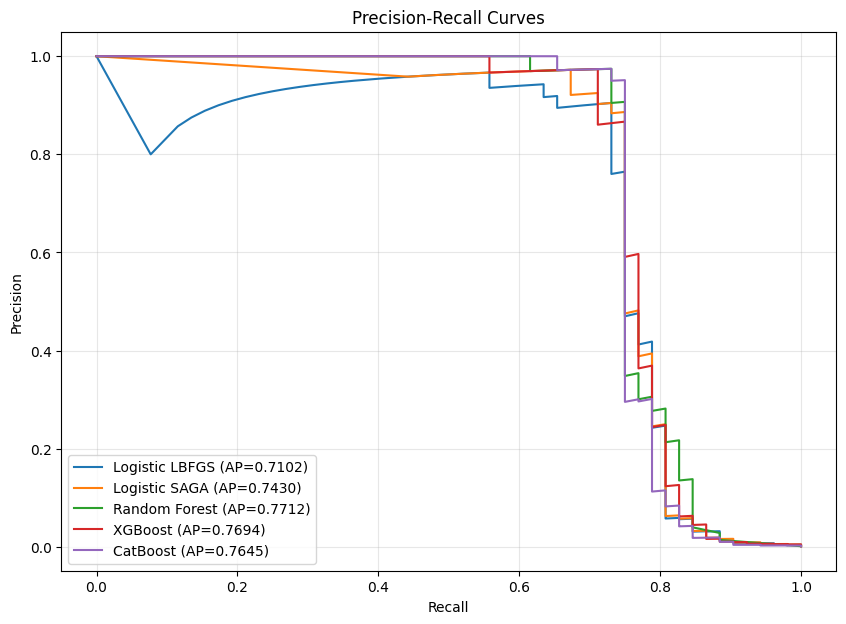

In [17]:
# 17. PRECISION-RECALL CURVES

models_prob = {
    "Logistic LBFGS": test_prob_lbfgs,
    "Logistic SAGA": test_prob_saga,
    "Random Forest": test_prob_rf,
    "XGBoost": test_prob_xgb,
    "CatBoost": test_prob_cat
}

plt.figure(figsize=(10, 7))

for name, prob in models_prob.items():
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

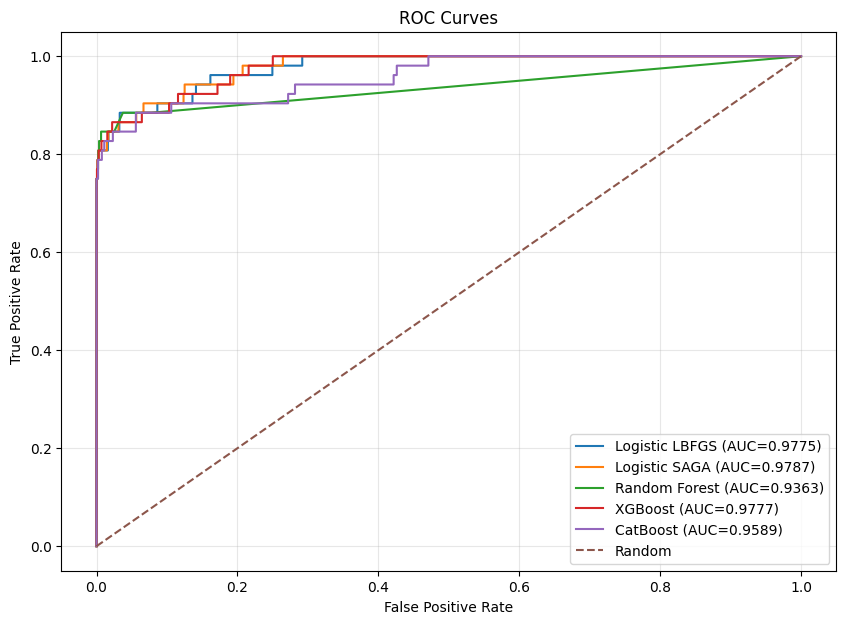

In [18]:
# 18. ROC CURVES

plt.figure(figsize=(10, 7))

for name, prob in models_prob.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.4f})")

plt.plot([0, 1], [0, 1], "--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [19]:
# 19. THRESHOLD OPTIMIZATION

# Example business requirement:
# Find the threshold that gives at least 80% recall
# while maximizing precision.

best_model_name = results_df.sort_values(
    "PR_AUC", ascending=False
).iloc[0]["Model"]

best_probs = {
    "Logistic Regression - LBFGS": test_prob_lbfgs,
    "Logistic Regression - SAGA": test_prob_saga,
    "Random Forest": test_prob_rf,
    "XGBoost": test_prob_xgb,
    "CatBoost": test_prob_cat
}[best_model_name]

threshold_rows = []

for threshold in np.arange(0.01, 1.00, 0.01):
    pred = (best_probs >= threshold).astype(int)

    precision = precision_score(y_test, pred, zero_division=0)
    recall = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)

    threshold_rows.append([
        threshold, precision, recall, f1
    ])

threshold_df = pd.DataFrame(
    threshold_rows,
    columns=["Threshold", "Precision", "Recall", "F1"]
)

eligible = threshold_df[
    threshold_df["Recall"] >= 0.80
]

if len(eligible) > 0:
    optimal = eligible.sort_values(
        "Precision",
        ascending=False
    ).iloc[0]
else:
    optimal = threshold_df.sort_values(
        "F1",
        ascending=False
    ).iloc[0]

print("Model:", best_model_name)
print("Selected threshold:", round(optimal["Threshold"], 2))
print("Precision:", round(optimal["Precision"], 4))
print("Recall:", round(optimal["Recall"], 4))
print("F1:", round(optimal["F1"], 4))

Model: Random Forest
Selected threshold: 0.02
Precision: 0.2308
Recall: 0.8077
F1: 0.359


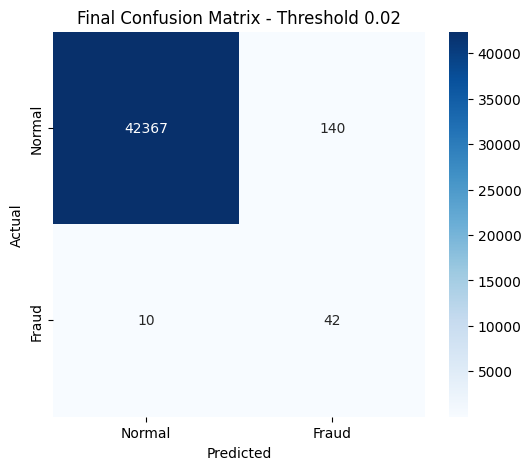

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     42507
       Fraud       0.23      0.81      0.36        52

    accuracy                           1.00     42559
   macro avg       0.62      0.90      0.68     42559
weighted avg       1.00      1.00      1.00     42559



In [20]:
# 20. FINAL CONFUSION MATRIX USING OPTIMIZED THRESHOLD

final_threshold = float(optimal["Threshold"])
final_pred = (best_probs >= final_threshold).astype(int)

cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(
    f"Final Confusion Matrix - Threshold {final_threshold:.2f}"
)
plt.show()

print(classification_report(
    y_test,
    final_pred,
    target_names=["Normal", "Fraud"],
    zero_division=0
))

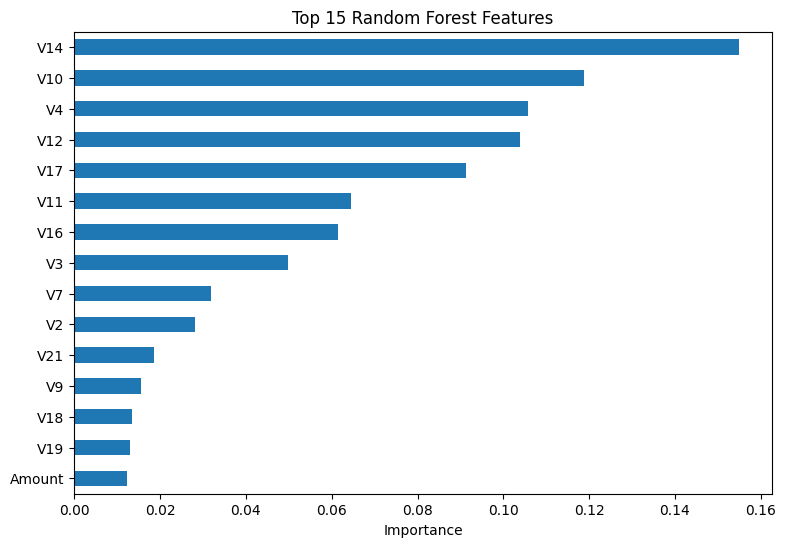

,0
V14,0.154809
V10,0.118808
V4,0.105684
V12,0.103916
V17,0.091200
V11,0.064542
V16,0.061529
V3,0.049857
V7,0.031950
V2,0.028041


In [21]:
# 21. FEATURE IMPORTANCE — RANDOM FOREST

importance = pd.Series(
    rf.feature_importances_,
    index=feature_cols
).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
importance.sort_values().plot(kind="barh")
plt.title("Top 15 Random Forest Features")
plt.xlabel("Importance")
plt.show()

display(importance)

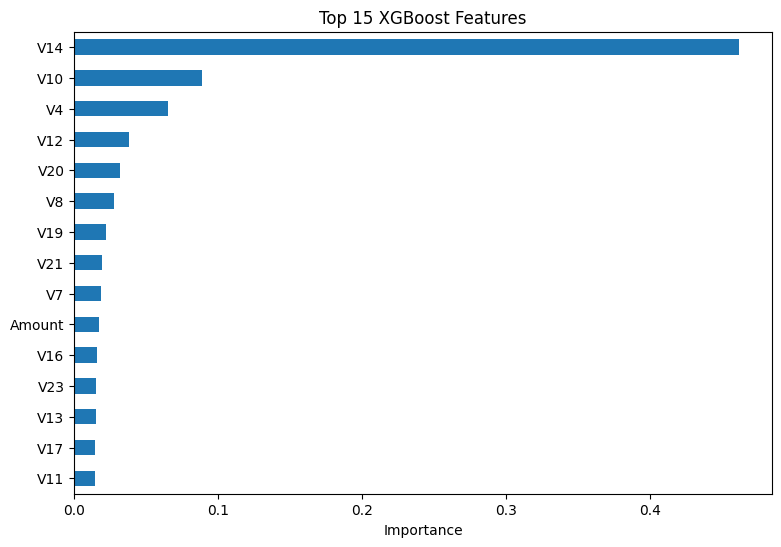

,0
V14,0.461247
V10,0.089047
V4,0.065313
V12,0.037879
V20,0.031748
V8,0.027339
V19,0.021992
V21,0.018994
V7,0.018483
Amount,0.017196


In [22]:
# 22. FEATURE IMPORTANCE — XGBOOST

xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=feature_cols
).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
xgb_importance.sort_values().plot(kind="barh")
plt.title("Top 15 XGBoost Features")
plt.xlabel("Importance")
plt.show()

display(xgb_importance)

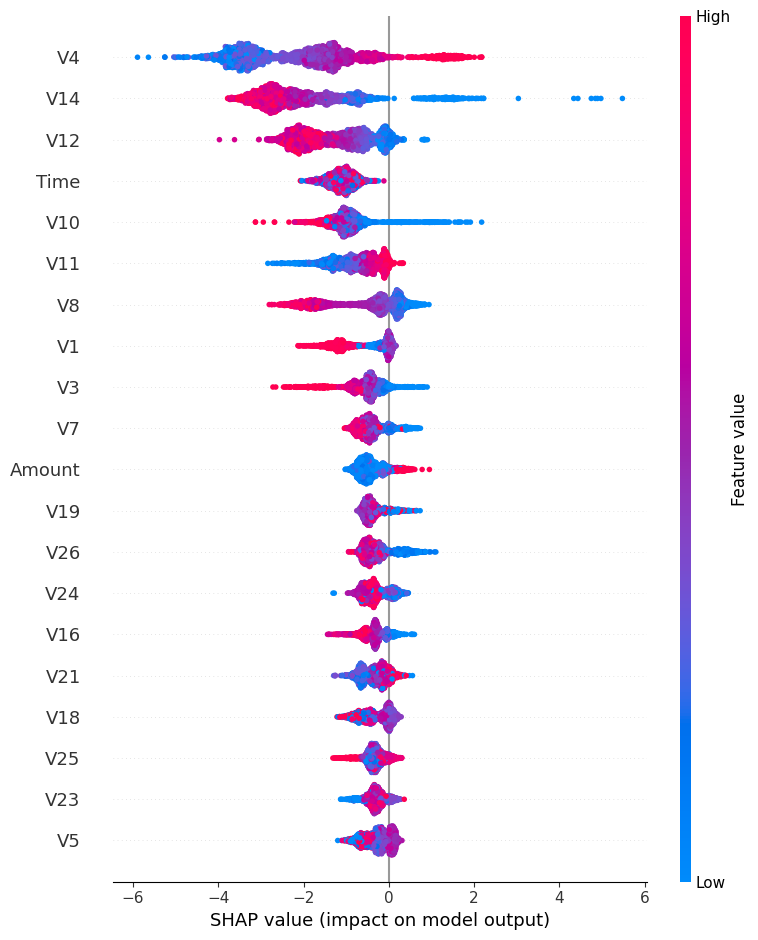

In [23]:
# 23. SHAP EXPLAINABILITY — XGBOOST

# SHAP explains which features push predictions toward fraud
# or toward normal.

sample_size = min(3000, len(X_test))
X_shap = X_test.iloc[:sample_size]

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_cols
)

In [24]:
# 24. NEURAL NETWORK DATA PREPARATION

X_train_nn = X_train.values.astype("float32")
X_val_nn = X_val.values.astype("float32")
X_test_nn = X_test.values.astype("float32")

y_train_nn = y_train.values.astype("float32")
y_val_nn = y_val.values.astype("float32")
y_test_nn = y_test.values.astype("float32")

print(X_train_nn.shape, X_val_nn.shape, X_test_nn.shape)

(198608, 30) (42559, 30) (42559, 30)


In [25]:
# 25. NEURAL NETWORK MODEL BUILDER

def build_nn(optimizer):
    model = Sequential([
        Input(shape=(X_train_nn.shape[1],)),
        Dense(64, activation="relu"),
        Dropout(0.30),
        Dense(32, activation="relu"),
        Dropout(0.20),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="roc_auc"),
            tf.keras.metrics.AUC(
                name="pr_auc",
                curve="PR"
            )
        ]
    )

    return model

In [26]:
# 26. NEURAL NETWORK — ADAM

nn_adam = build_nn(
    Adam(learning_rate=0.001)
)

history_adam = nn_adam.fit(
    X_train_nn,
    y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=15,
    batch_size=1024,
    class_weight={0: 1.0, 1: scale_pos_weight},
    verbose=1
)

nn_prob_adam = nn_adam.predict(
    X_test_nn,
    verbose=0
).ravel()

evaluate_model(
    "Neural Network - Adam",
    y_test,
    nn_prob_adam
)

Epoch 1/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.6993 - pr_auc: 0.5768 - precision: 0.0118 - recall: 0.8634 - roc_auc: 0.9189 - val_loss: 0.3039 - val_pr_auc: 0.8335 - val_precision: 0.0309 - val_recall: 0.8909 - val_roc_auc: 0.9519
Epoch 2/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4117 - pr_auc: 0.6848 - precision: 0.0630 - recall: 0.8962 - roc_auc: 0.9660 - val_loss: 0.1691 - val_pr_auc: 0.8153 - val_precision: 0.0549 - val_recall: 0.9091 - val_roc_auc: 0.9794
Epoch 3/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3470 - pr_auc: 0.6650 - precision: 0.0638 - recall: 0.9098 - roc_auc: 0.9732 - val_loss: 0.1172 - val_pr_auc: 0.8142 - val_precision: 0.0672 - val_recall: 0.9091 - val_roc_auc: 0.9829
Epoch 4/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2817 - pr_auc: 0.6476 - precision: 0.0641 - recall: 0.9208 - roc_auc: 0.9851 - val_loss: 0.0695 - val_pr_auc: 0.7661 - val_precision: 0.1073 - val_recall: 0.9091 - val_roc_auc: 0.9844
Epoch 5/15
194/1

{'Model': 'Neural Network - Adam',
 'Threshold': 0.5,
 'Accuracy': 0.9935618788035433,
 'Precision': 0.13486842105263158,
 'Recall': 0.7884615384615384,
 'F1': 0.2303370786516854,
 'ROC_AUC': np.float64(0.9849468232381635),
 'PR_AUC': np.float64(0.7620483641736323)}

In [27]:
# 27. NEURAL NETWORK — RMSPROP

nn_rmsprop = build_nn(
    RMSprop(learning_rate=0.001)
)

history_rmsprop = nn_rmsprop.fit(
    X_train_nn,
    y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=15,
    batch_size=1024,
    class_weight={0: 1.0, 1: scale_pos_weight},
    verbose=1
)

nn_prob_rmsprop = nn_rmsprop.predict(
    X_test_nn,
    verbose=0
).ravel()

evaluate_model(
    "Neural Network - RMSprop",
    y_test,
    nn_prob_rmsprop
)

Epoch 1/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.5299 - pr_auc: 0.5615 - precision: 0.0257 - recall: 0.8634 - roc_auc: 0.9466 - val_loss: 0.0480 - val_pr_auc: 0.8543 - val_precision: 0.2513 - val_recall: 0.9091 - val_roc_auc: 0.9813
Epoch 2/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.4071 - pr_auc: 0.6744 - precision: 0.1156 - recall: 0.8880 - roc_auc: 0.9698 - val_loss: 0.0267 - val_pr_auc: 0.8584 - val_precision: 0.2857 - val_recall: 0.9091 - val_roc_auc: 0.9805
Epoch 3/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4155 - pr_auc: 0.6697 - precision: 0.1251 - recall: 0.8907 - roc_auc: 0.9740 - val_loss: 0.0319 - val_pr_auc: 0.8378 - val_precision: 0.2000 - val_recall: 0.9091 - val_roc_auc: 0.9845
Epoch 4/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4089 - pr_auc: 0.6601 - precision: 0.1183 - recall: 0.8907 - roc_auc: 0.9759 - val_loss: 0.0372 - val_pr_auc: 0.7383 - val_precision: 0.1599 - val_recall: 0.9273 - val_roc_auc: 0.9859
Epoch 5/15
194/

{'Model': 'Neural Network - RMSprop',
 'Threshold': 0.5,
 'Accuracy': 0.9973448624262788,
 'Precision': 0.28368794326241137,
 'Recall': 0.7692307692307693,
 'F1': 0.41450777202072536,
 'ROC_AUC': np.float64(0.9824069700737073),
 'PR_AUC': np.float64(0.7721319043354353)}

In [28]:
# 28. NEURAL NETWORK — SGD

nn_sgd = build_nn(
    SGD(
        learning_rate=0.01,
        momentum=0.9,
        nesterov=True
    )
)

history_sgd = nn_sgd.fit(
    X_train_nn,
    y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=15,
    batch_size=1024,
    class_weight={0: 1.0, 1: scale_pos_weight},
    verbose=1
)

nn_prob_sgd = nn_sgd.predict(
    X_test_nn,
    verbose=0
).ravel()

evaluate_model(
    "Neural Network - SGD",
    y_test,
    nn_prob_sgd
)

Epoch 1/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.6540 - pr_auc: 0.1660 - precision: 0.0206 - recall: 0.8825 - roc_auc: 0.9526 - val_loss: 0.1381 - val_pr_auc: 0.5585 - val_precision: 0.0546 - val_recall: 0.9273 - val_roc_auc: 0.9863
Epoch 2/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4720 - pr_auc: 0.2940 - precision: 0.0399 - recall: 0.9071 - roc_auc: 0.9717 - val_loss: 0.0666 - val_pr_auc: 0.6373 - val_precision: 0.0785 - val_recall: 0.9273 - val_roc_auc: 0.9865
Epoch 3/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.8870 - pr_auc: 0.0653 - precision: 0.0265 - recall: 0.8880 - roc_auc: 0.9535 - val_loss: 0.1814 - val_pr_auc: 0.1111 - val_precision: 0.0425 - val_recall: 0.8909 - val_roc_auc: 0.9760
Epoch 4/15
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.8399 - pr_auc: 0.1622 - precision: 0.0477 - recall: 0.8989 - roc_auc: 0.9706 - val_loss: 0.1052 - val_pr_auc: 0.5952 - val_precision: 0.0878 - val_recall: 0.9273 - val_roc_auc: 0.9793
Epoch 5/15
194/1

{'Model': 'Neural Network - SGD',
 'Threshold': 0.5,
 'Accuracy': 0.9927629878521582,
 'Precision': 0.12352941176470589,
 'Recall': 0.8076923076923077,
 'F1': 0.21428571428571427,
 'ROC_AUC': np.float64(0.970647142280638),
 'PR_AUC': np.float64(0.6945141562566871)}

In [29]:
# 29. OPTIMIZER COMPARISON

optimizer_results = pd.DataFrame([
    r for r in results
    if "Neural Network" in r["Model"]
])

display(
    optimizer_results.sort_values(
        "PR_AUC",
        ascending=False
    )
)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
1,Neural Network - RMSprop,0.5,0.997345,0.283688,0.769231,0.414508,0.982407,0.772132
0,Neural Network - Adam,0.5,0.993562,0.134868,0.788462,0.230337,0.984947,0.762048
2,Neural Network - SGD,0.5,0.992763,0.123529,0.807692,0.214286,0.970647,0.694514


In [30]:
# 30. FINAL MODEL COMPARISON

final_results = pd.DataFrame(results)

display(
    final_results.sort_values(
        ["PR_AUC", "F1"],
        ascending=False
    ).reset_index(drop=True)
)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Neural Network - RMSprop,0.5,0.997345,0.283688,0.769231,0.414508,0.982407,0.772132
1,Random Forest,0.5,0.999601,0.972973,0.692308,0.808989,0.936324,0.771208
2,XGBoost,0.5,0.999554,0.866667,0.750000,0.804124,0.977676,0.769369
3,CatBoost,0.5,0.999483,0.812500,0.750000,0.780000,0.958905,0.764478
4,Neural Network - Adam,0.5,0.993562,0.134868,0.788462,0.230337,0.984947,0.762048
5,Logistic Regression - SAGA,0.5,0.982659,0.056848,0.846154,0.106538,0.978713,0.742984
6,Logistic Regression - LBFGS,0.5,0.982377,0.055980,0.846154,0.105012,0.977454,0.710154
7,Neural Network - SGD,0.5,0.992763,0.123529,0.807692,0.214286,0.970647,0.694514


In [31]:
# 31. FINAL FRAUD PREDICTION FUNCTION

# Uses the selected tree-based model and optimized threshold.

def predict_fraud(transaction, threshold=final_threshold):
    transaction_df = pd.DataFrame([transaction])

    transaction_df[["Time", "Amount"]] = scaler.transform(
        transaction_df[["Time", "Amount"]]
    )

    probability = xgb.predict_proba(transaction_df[feature_cols])[:, 1][0]

    prediction = "FRAUD" if probability >= threshold else "NORMAL"

    return {
        "fraud_probability": float(probability),
        "prediction": prediction,
        "threshold": float(threshold)
    }

print("Prediction function ready.")

Prediction function ready.


In [32]:
# 32. TEST THE FRAUD PREDICTION FUNCTION

sample_transaction = X_test.iloc[0].copy()

# X_test currently contains scaled Time/Amount,
# so recover original values for the demo.
sample_transaction["Time"] = test_df.iloc[0]["Time"]
sample_transaction["Amount"] = test_df.iloc[0]["Amount"]

result = predict_fraud(
    sample_transaction.to_dict()
)

print(result)

{'fraud_probability': 1.8204569869340048e-06, 'prediction': 'NORMAL', 'threshold': 0.02}


In [33]:
# 33. SAVE FINAL MODEL + SCALER

import joblib

joblib.dump(xgb, "/content/fraud_xgboost_model.pkl")
joblib.dump(scaler, "/content/fraud_scaler.pkl")

print("Model saved:")
print("/content/fraud_xgboost_model.pkl")
print("/content/fraud_scaler.pkl")

Model saved:
/content/fraud_xgboost_model.pkl
/content/fraud_scaler.pkl


In [34]:
# 34. SAVE RESULTS

final_results.to_csv(
    "/content/model_comparison_results.csv",
    index=False
)

print("Results saved to:")
print("/content/model_comparison_results.csv")

Results saved to:
/content/model_comparison_results.csv


In [35]:
# 35. FINAL PROJECT SUMMARY

print("=" * 60)
print("CREDIT CARD FRAUD DETECTION — FINAL SUMMARY")
print("=" * 60)

print(f"Dataset size: {len(df):,}")
print(f"Fraud rate: {df['Class'].mean() * 100:.4f}%")
print(f"Selected model: {best_model_name}")
print(f"Selected threshold: {final_threshold:.2f}")

final_metrics = evaluate_model(
    "Final Selected Model",
    y_test,
    best_probs,
    final_threshold
)

print("\nFinal Metrics:")
for key, value in final_metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

CREDIT CARD FRAUD DETECTION — FINAL SUMMARY
Dataset size: 283,726
Fraud rate: 0.1667%
Selected model: Random Forest
Selected threshold: 0.02

Final Metrics:
Model: Final Selected Model
Threshold: 0.0200
Accuracy: 0.9965
Precision: 0.2308
Recall: 0.8077
F1: 0.3590
ROC_AUC: 0.9363
PR_AUC: 0.7712


# Production-Style Software Extension

This section turns the ML notebook into a company-presentation prototype: **ML model → risk engine → FastAPI → SQLite logging → Streamlit dashboard → monitoring → Docker**.

It is an educational prototype, not a production payment system.

In [36]:
# 36. CREATE SOFTWARE PROJECT STRUCTURE
from pathlib import Path

project_root = Path('/content/fraud_detection_project')
for folder in ['api','dashboard','models','monitoring','tests']:
    (project_root / folder).mkdir(parents=True, exist_ok=True)
print('Created:', project_root)

Created: /content/fraud_detection_project


In [37]:
# 37. SAVE MODEL, SCALER AND METADATA
import json, joblib

joblib.dump(xgb, project_root / 'models' / 'fraud_xgboost_model.pkl')
joblib.dump(scaler, project_root / 'models' / 'fraud_scaler.pkl')

metadata = {
    'model_name':'XGBoost', 'model_version':'1.0.0',
    'threshold':float(final_threshold), 'features':feature_cols,
    'target':'Class', 'smote_used':False,
    'validation':'chronological 70/15/15 split'
}
with open(project_root / 'models' / 'model_metadata.json','w') as f:
    json.dump(metadata,f,indent=2)
print('Model artifacts saved.')

Model artifacts saved.


In [38]:
# 38. CREATE RISK ENGINE
risk_engine = """def risk_level(p):
    if p < 0.30: return 'LOW'
    if p < 0.70: return 'MEDIUM'
    if p < 0.90: return 'HIGH'
    return 'CRITICAL'

def decision(p):
    if p < 0.30: return 'APPROVE'
    if p < 0.70: return 'ADDITIONAL_CHECK'
    if p < 0.90: return 'MANUAL_REVIEW'
    return 'BLOCK_OR_INVESTIGATE'
"""
(project_root/'api'/'risk_engine.py').write_text(risk_engine,encoding='utf-8')
print('Risk engine created.')

Risk engine created.


In [39]:
# 39. CREATE FASTAPI BACKEND
api_code = """from pathlib import Path
import json, sqlite3, time
import joblib, pandas as pd
from fastapi import FastAPI
from pydantic import BaseModel
from risk_engine import risk_level, decision

BASE=Path(__file__).resolve().parent.parent
MODEL_DIR=BASE/'models'
model=joblib.load(MODEL_DIR/'fraud_xgboost_model.pkl')
scaler=joblib.load(MODEL_DIR/'fraud_scaler.pkl')
with open(MODEL_DIR/'model_metadata.json') as f: metadata=json.load(f)
FEATURES=metadata['features']
DB_PATH=BASE/'fraud_predictions.db'
app=FastAPI(title='Credit Card Fraud Detection API',version=metadata['model_version'])

class Transaction(BaseModel):
    values: dict

def init_db():
    with sqlite3.connect(DB_PATH) as c:
        c.execute('CREATE TABLE IF NOT EXISTS predictions (id INTEGER PRIMARY KEY AUTOINCREMENT, created_at TEXT DEFAULT CURRENT_TIMESTAMP, fraud_probability REAL, risk_level TEXT, decision TEXT, model_version TEXT, latency_ms REAL)')
        c.commit()
init_db()

@app.get('/')
def root(): return {'service':'Credit Card Fraud Detection API','status':'running','model_version':metadata['model_version']}

@app.get('/health')
def health(): return {'status':'healthy'}

@app.post('/predict')
def predict(transaction: Transaction):
    start=time.perf_counter()
    missing=[f for f in FEATURES if f not in transaction.values]
    if missing: return {'error':'Missing required features','missing_features':missing}
    X=pd.DataFrame([[transaction.values[f] for f in FEATURES]],columns=FEATURES)
    X[['Time','Amount']]=scaler.transform(X[['Time','Amount']])
    p=float(model.predict_proba(X)[:,1][0])
    level=risk_level(p); action=decision(p)
    latency=(time.perf_counter()-start)*1000
    with sqlite3.connect(DB_PATH) as c:
        c.execute('INSERT INTO predictions (fraud_probability,risk_level,decision,model_version,latency_ms) VALUES (?,?,?,?,?)',(p,level,action,metadata['model_version'],latency)); c.commit()
    return {'fraud_probability':round(p,6),'risk_level':level,'decision':action,'model_version':metadata['model_version'],'latency_ms':round(latency,2)}
"""
(project_root/'api'/'main.py').write_text(api_code,encoding='utf-8')
print('FastAPI backend created.')

FastAPI backend created.


In [40]:
# 40. CREATE STREAMLIT DASHBOARD
dashboard_code = """from pathlib import Path
import sqlite3
import pandas as pd
import streamlit as st

BASE=Path(__file__).resolve().parent.parent
DB_PATH=BASE/'fraud_predictions.db'
st.set_page_config(page_title='Fraud Detection Monitor',page_icon='🛡️',layout='wide')
st.title('🛡️ Credit Card Fraud Detection Monitor')
st.caption('Production-style ML demonstration dashboard')

if not DB_PATH.exists():
    st.info('No prediction database found. Start the API and make a prediction.')
else:
    with sqlite3.connect(DB_PATH) as c: data=pd.read_sql_query('SELECT * FROM predictions ORDER BY id DESC',c)
    if data.empty: st.info('No predictions available.')
    else:
        a,b,c,d=st.columns(4)
        a.metric('Predictions',len(data))
        b.metric('High/Critical',int(data.risk_level.isin(['HIGH','CRITICAL']).sum()))
        c.metric('Avg Fraud Probability',f'{data.fraud_probability.mean():.2%}')
        d.metric('Avg Latency',f'{data.latency_ms.mean():.2f} ms')
        st.subheader('Risk Distribution'); st.bar_chart(data.risk_level.value_counts())
        st.subheader('Fraud Probability'); st.line_chart(data.set_index('id').fraud_probability)
        st.subheader('Recent Predictions'); st.dataframe(data.head(50),use_container_width=True)
"""
(project_root/'dashboard'/'app.py').write_text(dashboard_code,encoding='utf-8')
print('Dashboard created.')

Dashboard created.


In [41]:
# 41. CREATE MONITORING SCRIPT
monitor = """from pathlib import Path
import sqlite3, pandas as pd
DB_PATH=Path(__file__).resolve().parent.parent/'fraud_predictions.db'
if not DB_PATH.exists(): print('No prediction database found.')
else:
    with sqlite3.connect(DB_PATH) as c: df=pd.read_sql_query('SELECT * FROM predictions',c)
    print('Predictions:',len(df))
    if len(df):
        print('Average fraud probability:',round(df.fraud_probability.mean(),4))
        print('Average latency ms:',round(df.latency_ms.mean(),2))
        print('Risk distribution:'); print(df.risk_level.value_counts())
        print('Decision distribution:'); print(df.decision.value_counts())
"""
(project_root/'monitoring'/'monitor.py').write_text(monitor,encoding='utf-8')
print('Monitoring script created.')

Monitoring script created.


In [42]:
# 42. CREATE REQUIREMENTS.TXT
requirements = """fastapi
uvicorn
streamlit
pandas
numpy
scikit-learn
xgboost
catboost
joblib
pydantic
shap
matplotlib
seaborn
tensorflow
"""
(project_root/'requirements.txt').write_text(requirements,encoding='utf-8')
print(requirements)

fastapi
uvicorn
streamlit
pandas
numpy
scikit-learn
xgboost
catboost
joblib
pydantic
shap
matplotlib
seaborn
tensorflow



In [43]:
# 43. CREATE DOCKERFILE
dockerfile = """FROM python:3.11-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt
COPY . .
EXPOSE 8000
EXPOSE 8501
CMD ["uvicorn","api.main:app","--host","0.0.0.0","--port","8000"]
"""
(project_root/'Dockerfile').write_text(dockerfile,encoding='utf-8')
print('Dockerfile created.')

Dockerfile created.


In [44]:
# 44. CREATE README
readme = """# Credit Card Fraud Detection Platform

Advanced company-presentation prototype with chronological validation, cost-sensitive learning, Logistic Regression (LBFGS/SAGA), Random Forest, XGBoost, CatBoost, neural-network optimizer comparison (Adam/RMSprop/SGD), PR-AUC, threshold optimization, SHAP, risk scoring, FastAPI, SQLite logging, Streamlit monitoring and Docker.

## Run API
uvicorn api.main:app --reload

## Run dashboard
streamlit run dashboard/app.py

## Architecture
Dataset -> preprocessing -> ML -> threshold -> risk engine -> FastAPI -> SQLite -> Streamlit

This is an educational prototype. Production financial deployment requires security, authentication, encryption, governance, compliance, drift monitoring and extensive validation.
"""
(project_root/'README.md').write_text(readme,encoding='utf-8')
print('README created.')

README created.


In [45]:
# 45. CREATE .GITIGNORE
gitignore = """__pycache__/
*.pyc
.venv/
venv/
.env
.ipynb_checkpoints/
fraud_predictions.db
"""
(project_root/'.gitignore').write_text(gitignore,encoding='utf-8')
print('.gitignore created.')

.gitignore created.


In [46]:
# 46. CREATE API TEST SCRIPT
test = """import requests
r=requests.get('http://127.0.0.1:8000/health',timeout=5)
print(r.status_code,r.json())
"""
(project_root/'tests'/'test_api.py').write_text(test,encoding='utf-8')
print('API test created.')

API test created.


In [47]:
# 47. ZIP COMPLETE SOFTWARE PROJECT
import shutil
zip_path=shutil.make_archive('/content/Credit_Card_Fraud_Detection_Production','zip',root_dir='/content',base_dir='fraud_detection_project')
print(zip_path)

/content/Credit_Card_Fraud_Detection_Production.zip


In [48]:
# 48. SHOW PROJECT STRUCTURE
for p in sorted(project_root.rglob('*')):
    if p.is_file(): print(p.relative_to(project_root))

.gitignore
Dockerfile
README.md
api/main.py
api/risk_engine.py
dashboard/app.py
models/fraud_scaler.pkl
models/fraud_xgboost_model.pkl
models/model_metadata.json
monitoring/monitor.py
requirements.txt
tests/test_api.py


In [50]:
import os
import json
import joblib

os.makedirs("/content/models", exist_ok=True)

# Using the actual trained Random Forest model variable 'rf' from the notebook
joblib.dump(rf, "/content/models/fraud_model.joblib")

# Using the defined scaler variable
joblib.dump(scaler, "/content/models/scaler.joblib")

metadata = {
    "model_name": type(rf).__name__,
    "features": [
        "Time",
        "V1", "V2", "V3", "V4", "V5", "V6", "V7",
        "V8", "V9", "V10", "V11", "V12", "V13", "V14",
        "V15", "V16", "V17", "V18", "V19", "V20", "V21",
        "V22", "V23", "V24", "V25", "V26", "V27", "V28",
        "Amount"
    ],
    "threshold": float(final_threshold)
}

with open("/content/models/metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Model artifacts saved successfully!")

Model artifacts saved successfully!


In [51]:
!zip -r /content/models.zip /content/models

  adding: content/models/ (stored 0%)
  adding: content/models/fraud_model.joblib (deflated 68%)
  adding: content/models/scaler.joblib (deflated 40%)
  adding: content/models/metadata.json (deflated 69%)


In [53]:
from google.colab import files
files.download("/content/models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Company Presentation Story

**One-line description:** An end-to-end, explainable, cost-sensitive credit-card fraud detection platform with time-aware validation, ensemble ML, neural-network optimizer comparison, risk scoring, threshold optimization, SHAP explainability, API inference, database logging, monitoring and a web dashboard.

### Live demo sequence
1. Show the severe class imbalance.
2. Explain why SMOTE was avoided.
3. Show chronological validation.
4. Compare models using PR-AUC.
5. Show threshold optimization.
6. Show SHAP explanations.
7. Start FastAPI and call `/predict`.
8. Show probability, risk level, decision and latency.
9. Open the Streamlit dashboard.
10. Show prediction logs and monitoring.
11. Show the Docker/GitHub project structure.